# CSE438 Lab 09: Image Compression and Hough Transform

**Course:** CSE438 Digital Image Processing  
**Lab Topic:** Image Compression, Discrete Cosine Transform, Wavelet Transform, and Hough Transform  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Instructor:** Dr. Mohammad Rifat Ahmmad Rashid  

This lab connects two important topics in Digital Image Processing:

1. transform-domain image compression using **DCT** and **DWT**;
2. geometric feature detection using the **Hough transform**.

The Betel Leaf dataset is used for image-based compression experiments. For Hough line and circle detection, a small synthetic image is also created because natural leaf images may not contain clear straight lines or circular objects. This makes the algorithm behavior easier to verify before applying it to real images.

## Learning Objectives

After completing this lab, students should be able to:

- apply block-wise DCT for image compression;
- threshold transform coefficients and reconstruct an approximate image;
- compute MSE and PSNR for different coefficient-retention levels;
- apply wavelet decomposition and reconstruction using DWT;
- detect straight lines using the Hough transform;
- detect circles using the circular Hough transform;
- compare transform-domain compression results with visual and numerical evidence.

## Lab Tasks

| Task | Description |
|---:|---|
| 1 | Implement block DCT and threshold coefficients |
| 2 | Compute PSNR at different compression ratios |
| 3 | Apply DWT and reconstruct with different levels |
| 4 | Detect straight lines using Hough transform |
| 5 | Detect circles using circular Hough transform |

In [1]:
# ============================================================
# 1. Imports and basic configuration
# ============================================================

import os
import math
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import pywt
    PYWT_AVAILABLE = True
except Exception:
    PYWT_AVAILABLE = False
    print("PyWavelets is not available. In Kaggle, run: !pip install PyWavelets")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("/kaggle/working/cse438_lab09_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("PyWavelets available:", PYWT_AVAILABLE)
print("Output directory:", OUTPUT_DIR)

OpenCV version: 4.13.0
NumPy version: 2.4.6
PyWavelets available: True
Output directory: /kaggle/working/cse438_lab09_outputs


In [2]:
# ============================================================
# 2. Locate the Betel Leaf dataset in Kaggle
# ============================================================

CLASS_NAMES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

CANDIDATE_ROOTS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh/data"),
    Path("/kaggle/input"),
]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def looks_like_dataset_root(root: Path) -> bool:
    train_dir = root / "train"
    test_dir = root / "test"
    if not train_dir.exists() or not test_dir.exists():
        return False
    return all((train_dir / class_name).exists() for class_name in CLASS_NAMES)

def find_dataset_root() -> Path:
    for root in CANDIDATE_ROOTS:
        if looks_like_dataset_root(root):
            return root

    # Recursive fallback for Kaggle mounts with a slightly different parent name.
    base = Path("/kaggle/input")
    if base.exists():
        for train_dir in base.rglob("train"):
            possible_root = train_dir.parent
            if looks_like_dataset_root(possible_root):
                return possible_root

    raise FileNotFoundError(
        "Could not locate the dataset root. Add the Kaggle dataset to the notebook, "
        "then verify that it contains train/ and test/ folders with the four class names."
    )

DATASET_ROOT = find_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

print("Dataset root:", DATASET_ROOT)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train
Test directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test


In [3]:
# ============================================================
# 3. Build an image index and inspect class distribution
# ============================================================

def list_images(split_dir: Path, class_name: str):
    class_dir = split_dir / class_name
    return sorted([
        path for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ])

records = []
image_paths = {"train": {}, "test": {}}

for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for class_name in CLASS_NAMES:
        paths = list_images(split_dir, class_name)
        image_paths[split_name][class_name] = paths
        records.append({
            "Split": split_name,
            "Class": class_name,
            "Image Count": len(paths)
        })

count_df = pd.DataFrame(records)
display(count_df)

if count_df["Image Count"].min() == 0:
    raise RuntimeError("At least one class folder is empty. Please verify the dataset structure.")

,Split,Class,Image Count
0,train,Bacterial Leaf Disease,609
1,train,Dried Leaf,597
2,train,Fungal Brown Spot Disease,588
3,train,Healthy Leaf,594
4,test,Bacterial Leaf Disease,47
5,test,Dried Leaf,51
6,test,Fungal Brown Spot Disease,54
7,test,Healthy Leaf,49


In [4]:
# ============================================================
# 4. Utility functions for loading, visualization, and metrics
# ============================================================

def read_rgb(path: Path, target_size=(256, 256)) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if target_size is not None:
        rgb = cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)
    return rgb

def read_gray(path: Path, target_size=(256, 256)) -> np.ndarray:
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Could not read image: {path}")
    if target_size is not None:
        gray = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    return gray

def show_images(images, titles=None, cmap=None, cols=4, figsize=(16, 8)):
    n = len(images)
    rows = math.ceil(n / cols)
    plt.figure(figsize=figsize)
    for i, image in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image, cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def normalize_to_uint8(image: np.ndarray) -> np.ndarray:
    image_float = image.astype(np.float32)
    min_val, max_val = image_float.min(), image_float.max()
    if max_val - min_val < 1e-8:
        return np.zeros_like(image_float, dtype=np.uint8)
    out = (image_float - min_val) / (max_val - min_val) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)

def mse(original: np.ndarray, reconstructed: np.ndarray) -> float:
    original = original.astype(np.float32)
    reconstructed = reconstructed.astype(np.float32)
    return float(np.mean((original - reconstructed) ** 2))

def psnr(original: np.ndarray, reconstructed: np.ndarray, max_pixel_value=255.0) -> float:
    value = mse(original, reconstructed)
    if value == 0:
        return float("inf")
    return float(20 * np.log10(max_pixel_value / np.sqrt(value)))

def save_gray(name: str, image: np.ndarray):
    path = OUTPUT_DIR / name
    cv2.imwrite(str(path), image)
    return path

def save_rgb(name: str, image: np.ndarray):
    path = OUTPUT_DIR / name
    cv2.imwrite(str(path), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    return path

Selected image: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Healthy Leaf/Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg
Image shape: (256, 256)
Image dtype: uint8


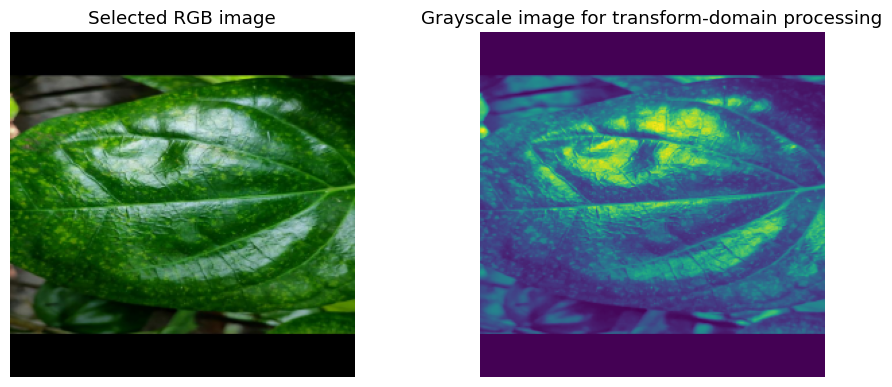

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_selected_gray.png')

In [5]:
# ============================================================
# 5. Select a representative image for compression experiments
# ============================================================

# Healthy leaves usually provide clear texture and shape for transformation experiments.
selected_class = "Healthy Leaf"
selected_path = image_paths["train"][selected_class][0]

rgb_image = read_rgb(selected_path, target_size=(256, 256))
gray_image = read_gray(selected_path, target_size=(256, 256))

print("Selected image:", selected_path)
print("Image shape:", gray_image.shape)
print("Image dtype:", gray_image.dtype)

show_images(
    [rgb_image, gray_image],
    ["Selected RGB image", "Grayscale image for transform-domain processing"],
    cmap=None,
    cols=2,
    figsize=(10, 4)
)

save_rgb("lab09_selected_rgb.png", rgb_image)
save_gray("lab09_selected_gray.png", gray_image)

## Task 1: Implement Block DCT and Threshold Coefficients

The 2D Discrete Cosine Transform expresses an image block as a weighted sum of cosine basis functions. In image compression, the main idea is that many high-frequency coefficients can be removed while preserving the dominant visual structure.

In this lab, the image is divided into non-overlapping `8 x 8` blocks. DCT is computed for each block, coefficients are thresholded by magnitude, and the image is reconstructed using inverse DCT.

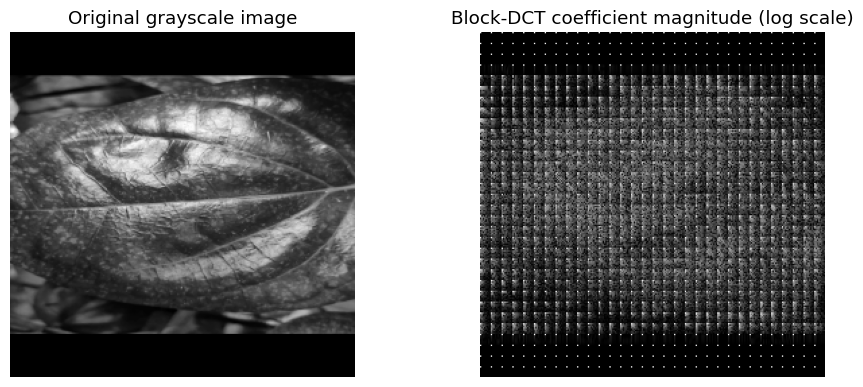

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_dct_magnitude_log.png')

In [6]:
# ============================================================
# 6. Block-wise DCT compression from scratch
# ============================================================

BLOCK_SIZE = 8

def crop_to_block_multiple(image: np.ndarray, block_size=8) -> np.ndarray:
    h, w = image.shape[:2]
    h_new = (h // block_size) * block_size
    w_new = (w // block_size) * block_size
    return image[:h_new, :w_new].copy()

def block_dct_coefficients(image: np.ndarray, block_size=8) -> np.ndarray:
    image = crop_to_block_multiple(image, block_size)
    h, w = image.shape
    coeffs = np.zeros((h, w), dtype=np.float32)

    for r in range(0, h, block_size):
        for c in range(0, w, block_size):
            block = image[r:r+block_size, c:c+block_size].astype(np.float32)
            block = block - 128.0
            coeffs[r:r+block_size, c:c+block_size] = cv2.dct(block)

    return coeffs

def inverse_block_dct(coeffs: np.ndarray, block_size=8) -> np.ndarray:
    h, w = coeffs.shape
    reconstructed = np.zeros((h, w), dtype=np.float32)

    for r in range(0, h, block_size):
        for c in range(0, w, block_size):
            block_coeff = coeffs[r:r+block_size, c:c+block_size].astype(np.float32)
            block = cv2.idct(block_coeff) + 128.0
            reconstructed[r:r+block_size, c:c+block_size] = block

    return np.clip(reconstructed, 0, 255).astype(np.uint8)

def retain_largest_coefficients(coeffs: np.ndarray, keep_ratio: float) -> tuple:
    keep_ratio = float(np.clip(keep_ratio, 0.0, 1.0))
    flat_abs = np.abs(coeffs).ravel()
    total = flat_abs.size
    keep_count = max(1, int(round(total * keep_ratio)))

    if keep_count >= total:
        mask = np.ones_like(coeffs, dtype=bool)
    else:
        threshold = np.partition(flat_abs, total - keep_count)[total - keep_count]
        mask = np.abs(coeffs) >= threshold

    compressed_coeffs = coeffs * mask
    actual_keep_ratio = float(np.count_nonzero(mask) / total)

    return compressed_coeffs, actual_keep_ratio

dct_coeffs = block_dct_coefficients(gray_image, block_size=BLOCK_SIZE)

# Visualize DCT magnitude in log scale.
dct_magnitude = np.log1p(np.abs(dct_coeffs))
dct_magnitude_vis = normalize_to_uint8(dct_magnitude)

show_images(
    [gray_image, dct_magnitude_vis],
    ["Original grayscale image", "Block-DCT coefficient magnitude (log scale)"],
    cmap="gray",
    cols=2,
    figsize=(10, 4)
)

save_gray("lab09_dct_magnitude_log.png", dct_magnitude_vis)

## Task 2: Compute PSNR at Different Compression Ratios

The following experiment keeps different percentages of DCT coefficients. A lower retained-coefficient ratio gives stronger compression but usually reduces PSNR and visual quality.

,Requested Keep Ratio,Actual Keep Ratio,Approx. Compression Ratio,MSE,PSNR
0,1.00,1.000000,1.000000,0.012329,67.221489
1,0.50,0.500000,2.000000,0.518082,50.986821
2,0.25,0.250000,4.000000,5.364365,40.835621
3,0.10,0.100037,9.996339,28.109344,33.642296
4,0.05,0.050003,19.998779,63.214310,30.122650
5,0.02,0.020004,49.989321,168.960083,25.852962
6,0.01,0.009995,100.054962,791.709045,19.145148


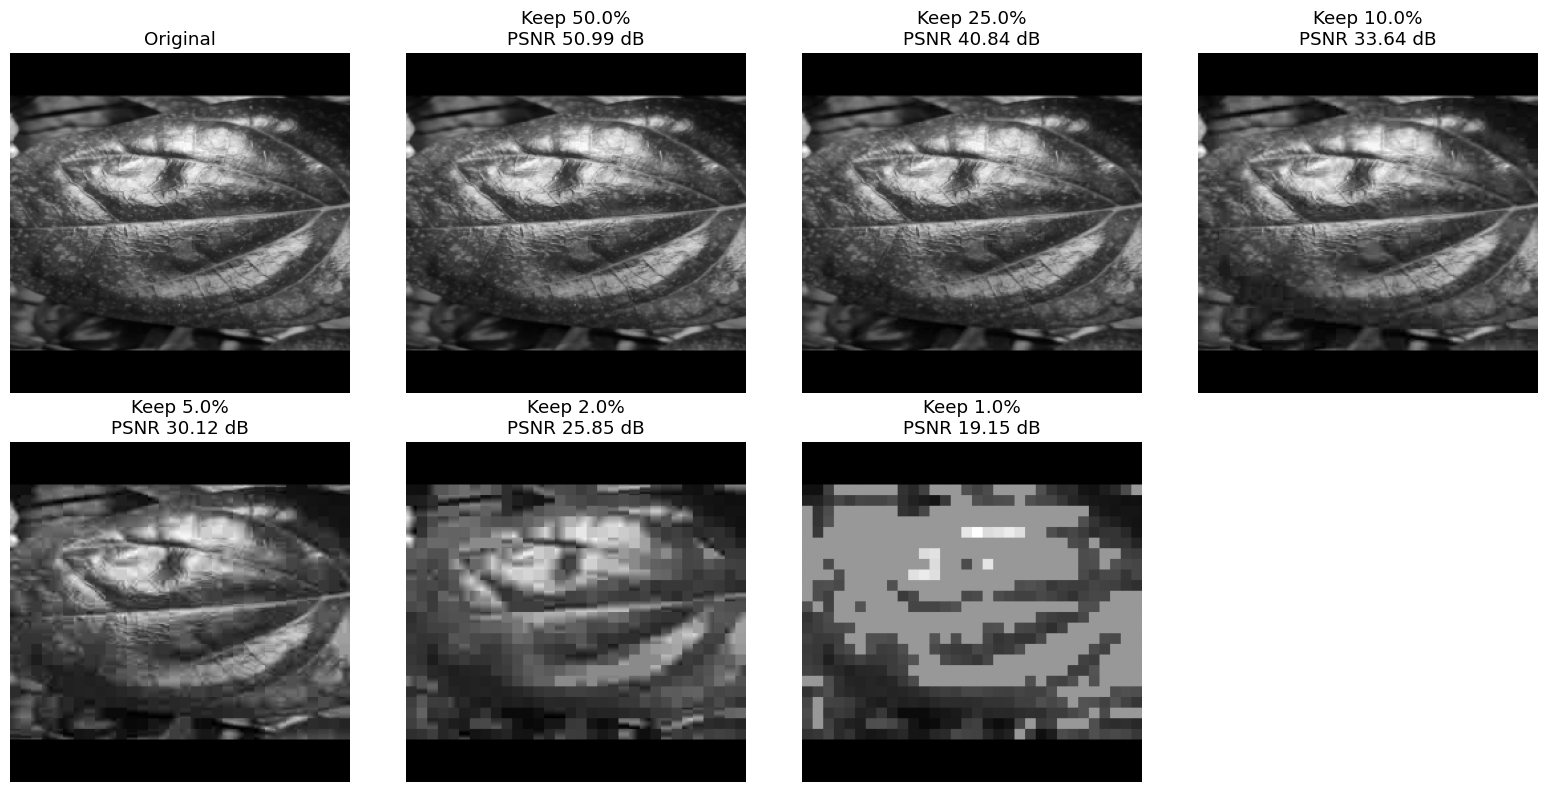

In [7]:
# ============================================================
# 7. DCT compression experiment with different keep ratios
# ============================================================

keep_ratios = [1.00, 0.50, 0.25, 0.10, 0.05, 0.02, 0.01]
dct_results = []
dct_images = []
dct_titles = []

for ratio in keep_ratios:
    compressed_coeffs, actual_ratio = retain_largest_coefficients(dct_coeffs, ratio)
    reconstructed = inverse_block_dct(compressed_coeffs, block_size=BLOCK_SIZE)

    result = {
        "Requested Keep Ratio": ratio,
        "Actual Keep Ratio": actual_ratio,
        "Approx. Compression Ratio": 1.0 / actual_ratio if actual_ratio > 0 else np.inf,
        "MSE": mse(gray_image, reconstructed),
        "PSNR": psnr(gray_image, reconstructed)
    }
    dct_results.append(result)
    dct_images.append(reconstructed)
    dct_titles.append(f"Keep {actual_ratio*100:.1f}%\nPSNR {result['PSNR']:.2f} dB")

    save_gray(f"lab09_dct_keep_{int(ratio*100):03d}.png", reconstructed)

dct_df = pd.DataFrame(dct_results)
display(dct_df)

show_images(
    [gray_image] + dct_images[1:],
    ["Original"] + dct_titles[1:],
    cmap="gray",
    cols=4,
    figsize=(16, 8)
)

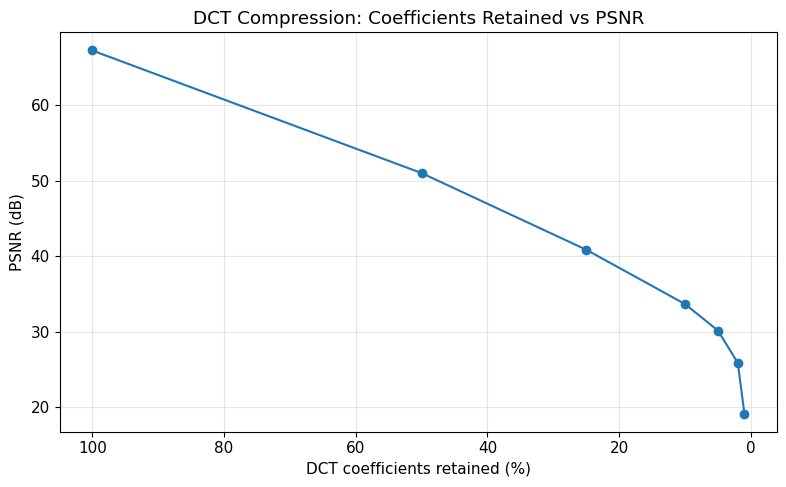

In [8]:
# ============================================================
# 8. Plot DCT compression ratio against PSNR
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(dct_df["Actual Keep Ratio"] * 100, dct_df["PSNR"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("DCT coefficients retained (%)")
plt.ylabel("PSNR (dB)")
plt.title("DCT Compression: Coefficients Retained vs PSNR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab09_dct_psnr_curve.png", dpi=150)
plt.show()

## Task 3: Apply DWT and Reconstruct with Different Levels

The Discrete Wavelet Transform separates an image into approximation and detail components. The approximation component stores coarse image structure, while detail components store horizontal, vertical, and diagonal changes.

Here, reconstruction is performed using only approximation coefficients at different decomposition levels. This demonstrates how wavelet-domain compression removes fine details progressively.

,Wavelet,Level,MSE,PSNR
0,haar,1,64.009872,30.068334
1,haar,2,170.571609,25.811736
2,haar,3,325.210693,23.009155
3,haar,4,549.822876,20.728576


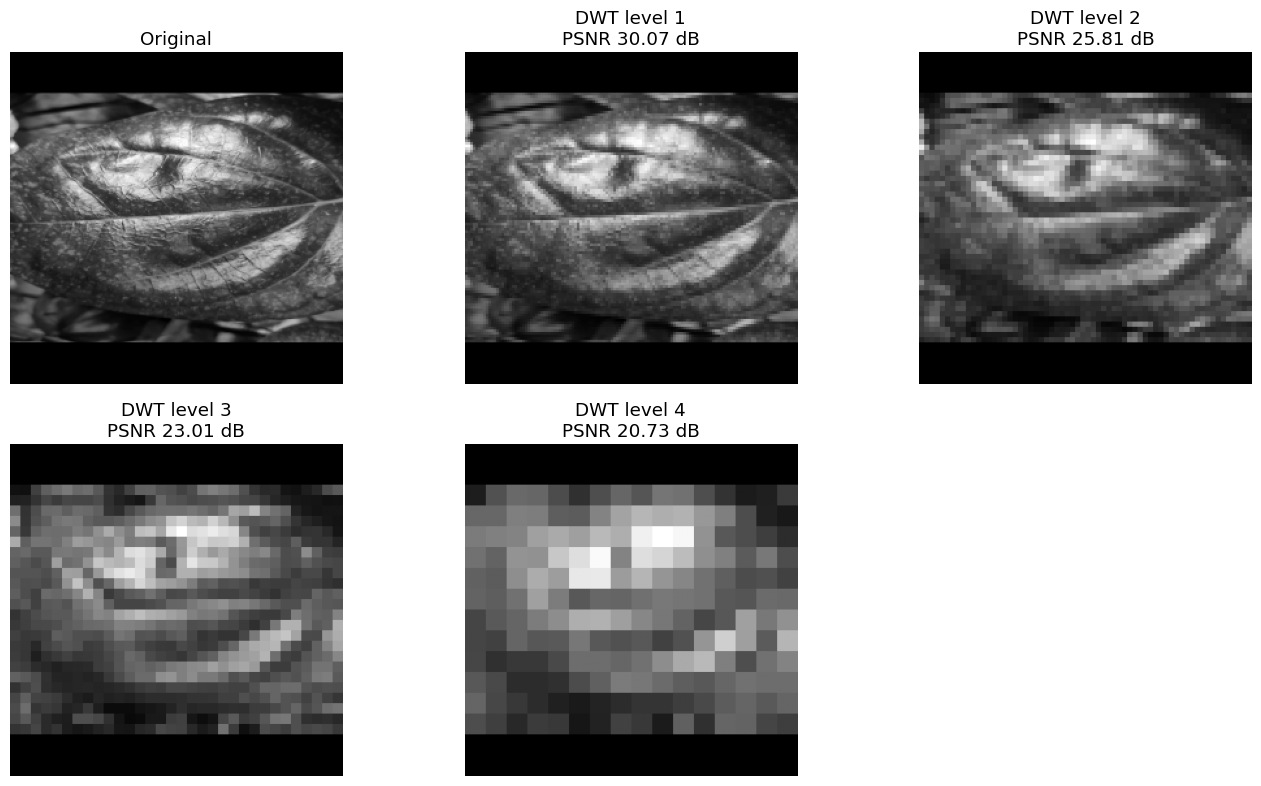

In [9]:
# ============================================================
# 9. DWT compression and reconstruction
# ============================================================

def dwt_approximation_reconstruct(image: np.ndarray, wavelet="haar", level=1) -> np.ndarray:
    if not PYWT_AVAILABLE:
        raise ImportError("PyWavelets is required for this section.")

    coeffs = pywt.wavedec2(image.astype(np.float32), wavelet=wavelet, level=level)

    # Keep approximation coefficient cA and set all detail coefficients to zero.
    approx_only_coeffs = [coeffs[0]]
    for detail in coeffs[1:]:
        cH, cV, cD = detail
        approx_only_coeffs.append((
            np.zeros_like(cH),
            np.zeros_like(cV),
            np.zeros_like(cD)
        ))

    reconstructed = pywt.waverec2(approx_only_coeffs, wavelet=wavelet)
    reconstructed = reconstructed[:image.shape[0], :image.shape[1]]
    return np.clip(reconstructed, 0, 255).astype(np.uint8)

if PYWT_AVAILABLE:
    dwt_levels = [1, 2, 3, 4]
    dwt_images = []
    dwt_results = []

    for level in dwt_levels:
        reconstructed = dwt_approximation_reconstruct(gray_image, wavelet="haar", level=level)
        dwt_images.append(reconstructed)

        result = {
            "Wavelet": "haar",
            "Level": level,
            "MSE": mse(gray_image, reconstructed),
            "PSNR": psnr(gray_image, reconstructed)
        }
        dwt_results.append(result)

        save_gray(f"lab09_dwt_haar_level_{level}.png", reconstructed)

    dwt_df = pd.DataFrame(dwt_results)
    display(dwt_df)

    show_images(
        [gray_image] + dwt_images,
        ["Original"] + [f"DWT level {level}\nPSNR {dwt_results[i]['PSNR']:.2f} dB" for i, level in enumerate(dwt_levels)],
        cmap="gray",
        cols=3,
        figsize=(14, 8)
    )
else:
    print("Skipping DWT section because PyWavelets is not available.")

In [10]:
# ============================================================
# 10. Compare DCT and DWT reconstruction quality
# ============================================================

comparison_rows = []

# Best compressed DCT setting excluding the lossless/full-retention case.
dct_subset = dct_df[dct_df["Actual Keep Ratio"] < 0.99].copy()
if len(dct_subset) > 0:
    best_dct = dct_subset.sort_values("PSNR", ascending=False).iloc[0]
    comparison_rows.append({
        "Method": "DCT",
        "Setting": f"Keep {best_dct['Actual Keep Ratio']*100:.1f}% coefficients",
        "MSE": best_dct["MSE"],
        "PSNR": best_dct["PSNR"]
    })

if PYWT_AVAILABLE:
    best_dwt = dwt_df.sort_values("PSNR", ascending=False).iloc[0]
    comparison_rows.append({
        "Method": "DWT",
        "Setting": f"Haar level {int(best_dwt['Level'])}, approximation only",
        "MSE": best_dwt["MSE"],
        "PSNR": best_dwt["PSNR"]
    })

compression_comparison_df = pd.DataFrame(comparison_rows)
display(compression_comparison_df)

,Method,Setting,MSE,PSNR
0,DCT,Keep 50.0% coefficients,0.518082,50.986821
1,DWT,"Haar level 1, approximation only",64.009872,30.068334


## Task 4: Detect Straight Lines Using Hough Transform

The Hough transform maps edge pixels into a parameter space. A straight line can be represented using distance and angle parameters. Strong peaks in the Hough space indicate probable line locations.

A synthetic geometric image is used first so that line detection can be clearly verified. The same method is then applied to the selected leaf image.

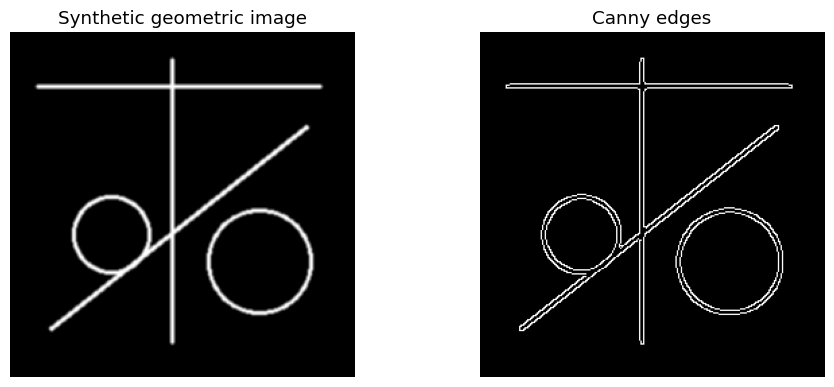

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_synthetic_edges.png')

In [11]:
# ============================================================
# 11. Create a synthetic image for stable Hough demonstration
# ============================================================

def create_synthetic_hough_image(size=256) -> np.ndarray:
    canvas = np.zeros((size, size), dtype=np.uint8)

    # Straight lines
    cv2.line(canvas, (20, 40), (230, 40), 255, 2)
    cv2.line(canvas, (30, 220), (220, 70), 255, 2)
    cv2.line(canvas, (120, 20), (120, 230), 255, 2)

    # Circles
    cv2.circle(canvas, (75, 150), 28, 255, 2)
    cv2.circle(canvas, (185, 170), 38, 255, 2)

    # Mild blur to make edge detection more realistic.
    canvas = cv2.GaussianBlur(canvas, (3, 3), 0)

    return canvas

synthetic_image = create_synthetic_hough_image()
synthetic_edges = cv2.Canny(synthetic_image, 50, 150)

show_images(
    [synthetic_image, synthetic_edges],
    ["Synthetic geometric image", "Canny edges"],
    cmap="gray",
    cols=2,
    figsize=(10, 4)
)

save_gray("lab09_synthetic_hough_image.png", synthetic_image)
save_gray("lab09_synthetic_edges.png", synthetic_edges)

Number of line segments detected in synthetic image: 8


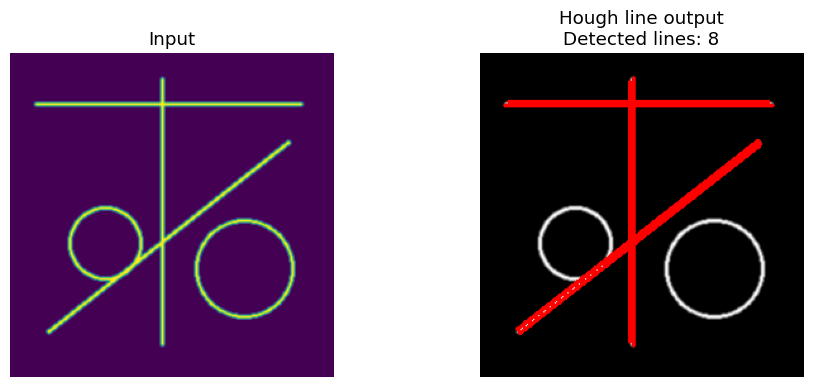

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_hough_lines_synthetic.png')

In [12]:
# ============================================================
# 12. Hough line detection on synthetic image
# ============================================================

def draw_hough_lines(base_gray: np.ndarray, edges: np.ndarray,
                     rho=1, theta=np.pi/180, threshold=60,
                     min_line_length=40, max_line_gap=8) -> tuple:
    color_output = cv2.cvtColor(base_gray, cv2.COLOR_GRAY2RGB)

    lines = cv2.HoughLinesP(
        edges,
        rho=rho,
        theta=theta,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    line_count = 0
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(color_output, (x1, y1), (x2, y2), (255, 0, 0), 2)
            line_count += 1

    return color_output, line_count

synthetic_lines_vis, synthetic_line_count = draw_hough_lines(
    synthetic_image,
    synthetic_edges,
    threshold=45,
    min_line_length=35,
    max_line_gap=10
)

print("Number of line segments detected in synthetic image:", synthetic_line_count)

show_images(
    [synthetic_image, synthetic_lines_vis],
    ["Input", f"Hough line output\nDetected lines: {synthetic_line_count}"],
    cmap=None,
    cols=2,
    figsize=(10, 4)
)

save_rgb("lab09_hough_lines_synthetic.png", synthetic_lines_vis)

Number of line segments detected in leaf image: 62


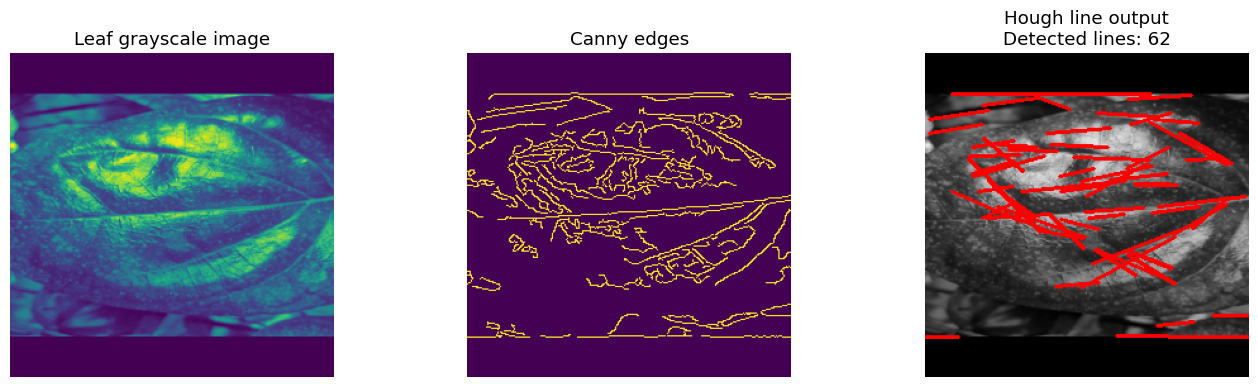

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_hough_lines_leaf.png')

In [13]:
# ============================================================
# 13. Hough line detection on Betel Leaf image
# ============================================================

leaf_blur = cv2.GaussianBlur(gray_image, (5, 5), 1.0)
leaf_edges = cv2.Canny(leaf_blur, 60, 160)

leaf_lines_vis, leaf_line_count = draw_hough_lines(
    gray_image,
    leaf_edges,
    threshold=35,
    min_line_length=25,
    max_line_gap=8
)

print("Number of line segments detected in leaf image:", leaf_line_count)

show_images(
    [gray_image, leaf_edges, leaf_lines_vis],
    ["Leaf grayscale image", "Canny edges", f"Hough line output\nDetected lines: {leaf_line_count}"],
    cmap=None,
    cols=3,
    figsize=(14, 4)
)

save_gray("lab09_leaf_edges_for_hough_lines.png", leaf_edges)
save_rgb("lab09_hough_lines_leaf.png", leaf_lines_vis)

## Task 5: Detect Circles Using Circular Hough Transform

Circular Hough transform searches for circular structures using center coordinates and radius. The synthetic image provides clear circular targets; the leaf image may not always contain natural circular structures, so detected circles on the leaf image should be interpreted cautiously.

Number of circles detected in synthetic image: 6


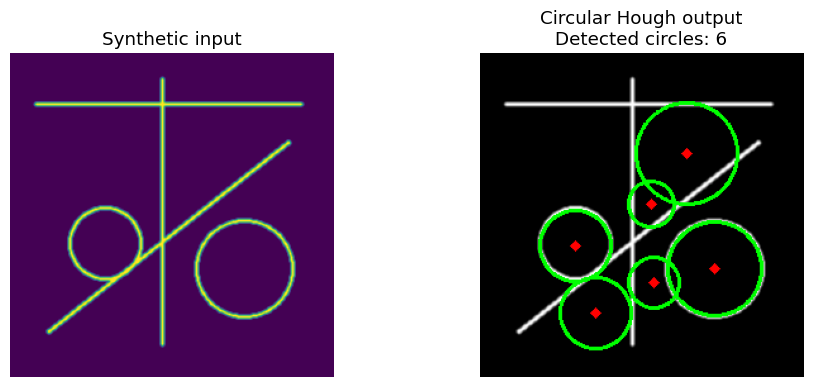

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_hough_circles_synthetic.png')

In [14]:
# ============================================================
# 14. Circular Hough transform on synthetic image
# ============================================================

def draw_hough_circles(base_gray: np.ndarray,
                       dp=1.2, min_dist=40,
                       param1=100, param2=20,
                       min_radius=10, max_radius=60) -> tuple:
    blurred = cv2.medianBlur(base_gray, 5)
    color_output = cv2.cvtColor(base_gray, cv2.COLOR_GRAY2RGB)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=dp,
        minDist=min_dist,
        param1=param1,
        param2=param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )

    circle_count = 0
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for circle in circles[0, :]:
            x, y, r = circle
            cv2.circle(color_output, (x, y), r, (0, 255, 0), 2)
            cv2.circle(color_output, (x, y), 2, (255, 0, 0), 3)
            circle_count += 1

    return color_output, circle_count

synthetic_circles_vis, synthetic_circle_count = draw_hough_circles(
    synthetic_image,
    dp=1.2,
    min_dist=45,
    param1=100,
    param2=16,
    min_radius=15,
    max_radius=45
)

print("Number of circles detected in synthetic image:", synthetic_circle_count)

show_images(
    [synthetic_image, synthetic_circles_vis],
    ["Synthetic input", f"Circular Hough output\nDetected circles: {synthetic_circle_count}"],
    cmap=None,
    cols=2,
    figsize=(10, 4)
)

save_rgb("lab09_hough_circles_synthetic.png", synthetic_circles_vis)

Number of circles detected in leaf image: 27


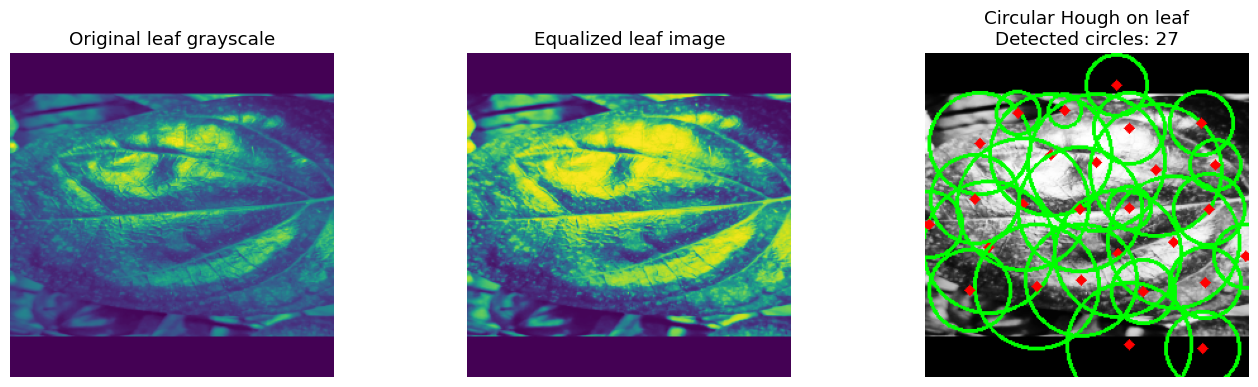

PosixPath('/kaggle/working/cse438_lab09_outputs/lab09_hough_circles_leaf.png')

In [15]:
# ============================================================
# 15. Circular Hough transform on Betel Leaf image
# ============================================================

leaf_for_circles = cv2.equalizeHist(gray_image)
leaf_circles_vis, leaf_circle_count = draw_hough_circles(
    leaf_for_circles,
    dp=1.2,
    min_dist=35,
    param1=100,
    param2=26,
    min_radius=8,
    max_radius=55
)

print("Number of circles detected in leaf image:", leaf_circle_count)

show_images(
    [gray_image, leaf_for_circles, leaf_circles_vis],
    ["Original leaf grayscale", "Equalized leaf image", f"Circular Hough on leaf\nDetected circles: {leaf_circle_count}"],
    cmap=None,
    cols=3,
    figsize=(14, 4)
)

save_rgb("lab09_hough_circles_leaf.png", leaf_circles_vis)

In [16]:
# ============================================================
# 16. Final method summary table
# ============================================================

summary_rows = [
    {
        "Part": "DCT Compression",
        "Main Parameter": "Coefficient keep ratio",
        "Observed Effect": "Lower keep ratio increases compression but reduces PSNR and may introduce blocking artifacts."
    },
    {
        "Part": "DWT Compression",
        "Main Parameter": "Wavelet level",
        "Observed Effect": "Higher approximation level removes more detail and creates smoother reconstruction."
    },
    {
        "Part": "Hough Lines",
        "Main Parameter": "Threshold, minLineLength, maxLineGap",
        "Observed Effect": "Higher threshold detects fewer but stronger line segments."
    },
    {
        "Part": "Hough Circles",
        "Main Parameter": "param2, radius range, minDist",
        "Observed Effect": "Strict settings reduce false circles, while loose settings may detect noisy circular patterns."
    }
]

method_summary_df = pd.DataFrame(summary_rows)
display(method_summary_df)

,Part,Main Parameter,Observed Effect
0,DCT Compression,Coefficient keep ratio,Lower keep ratio increases compression but red...
1,DWT Compression,Wavelet level,Higher approximation level removes more detail...
2,Hough Lines,"Threshold, minLineLength, maxLineGap",Higher threshold detects fewer but stronger li...
3,Hough Circles,"param2, radius range, minDist","Strict settings reduce false circles, while lo..."


In [17]:
# Summary:
# In this lab, we applied transform-domain compression using block-wise DCT and wavelet-based
# reconstruction, then evaluated reconstruction quality using MSE and PSNR. We also used
# Hough-based methods to detect straight lines and circles, first on a synthetic image for
# controlled verification and then on Betel Leaf images to observe practical behavior on
# natural image data.